Note: Code snippets and contents are based on course available at DataCamp. Also some contents are AI generated.

# Part 1: Getting started with LLMs


## Introduction to LLMs
Large Language Models (LLMs) are advanced artificial intelligence systems trained to understand and generate human-like text. They use deep learning techniques, particularly transformer architectures, to learn patterns in massive datasets containing text from books, websites, articles, and more.

Key features of LLMs:

Training: LLMs are trained on billions or even trillions of words to predict the next word in a sentence, learning grammar, facts, reasoning, and context in the process.

Applications: They power applications like chatbots (e.g., ChatGPT), text summarization, translation, coding assistance, and more.

Examples: GPT-4 by OpenAI, Claude by Anthropic, Gemini by Google, and LLaMA by Meta.

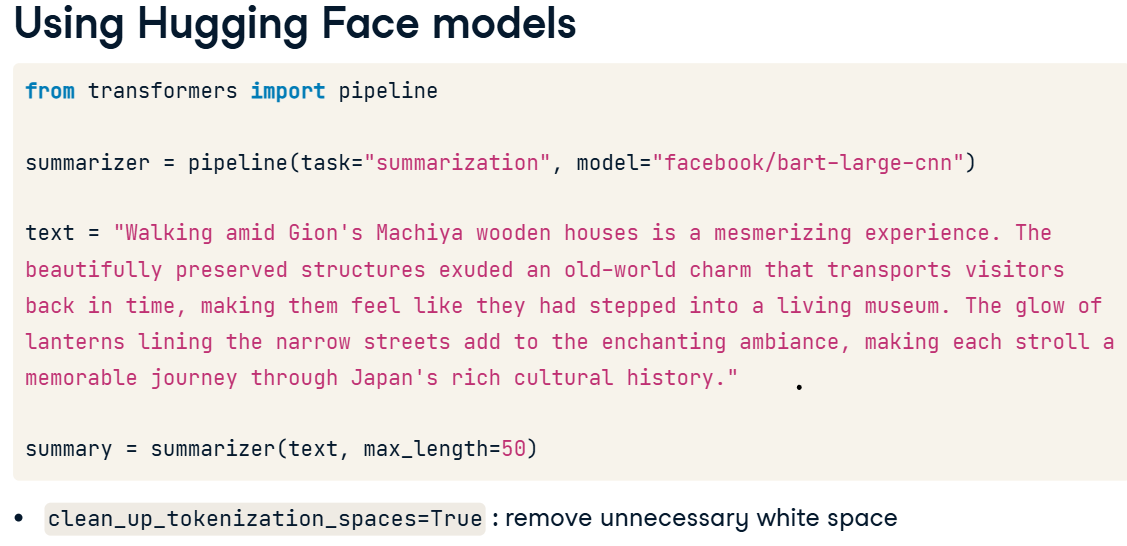

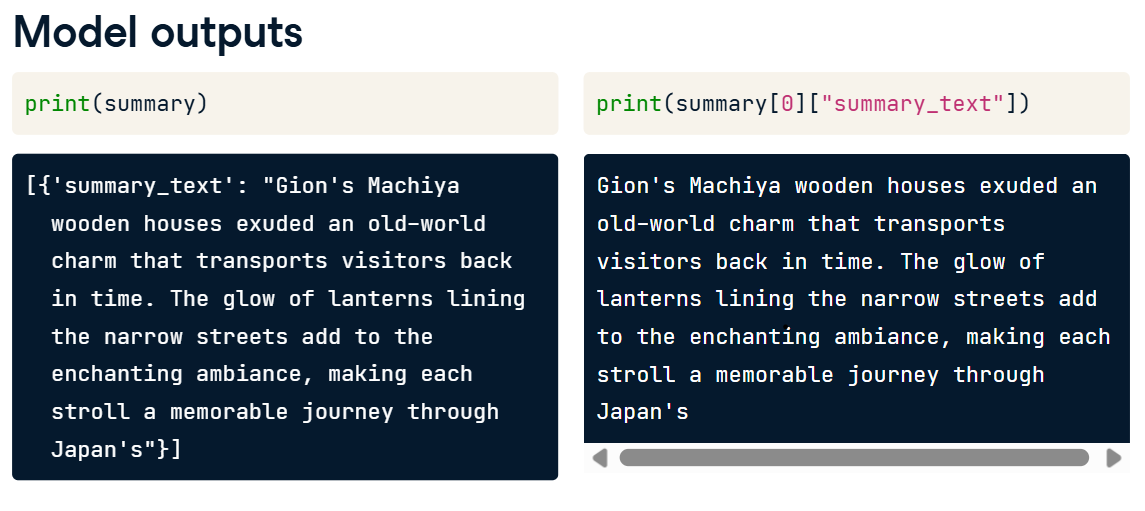

## Using pre-trained LLMs
Text generation involves producing coherent, meaningful, human-like text.

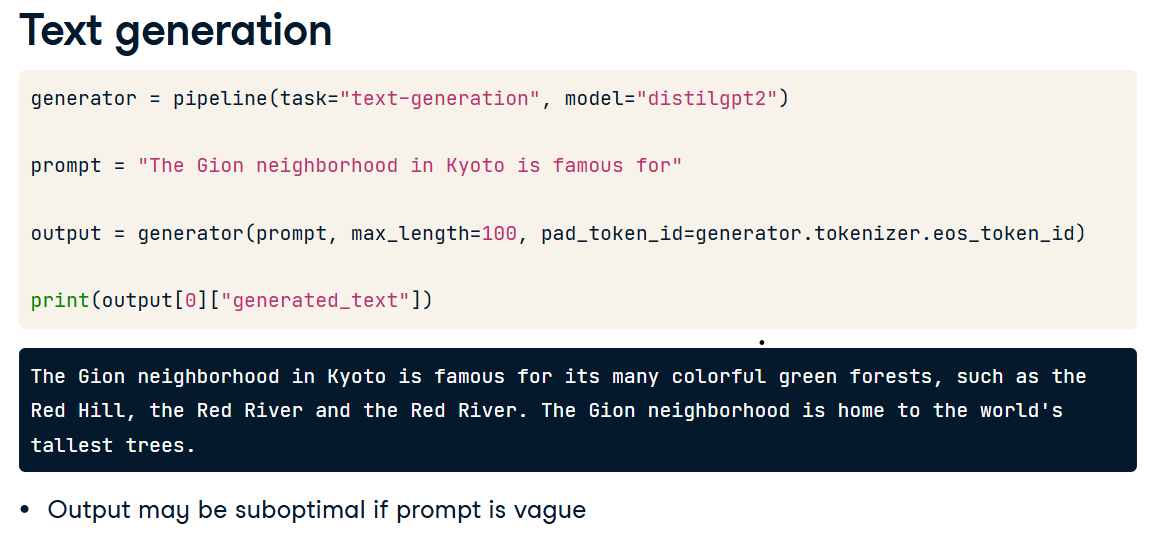

The pad_token_id parameter fills in extra space up to the specified max_length through padding, which adds extra tokens to make all sequences the same length, ensuring model efficiency. Setting this parameter to the tokenizer's end-of-sequence token ID, learned through training, marks the end of meaningful text. This setting helps the model recognize where to stop generating, ensuring it only produces text up to the specified length or the end-of-sequence token. Another parameter, truncation=True, can be added if the input is longer than the maximum length we have set.

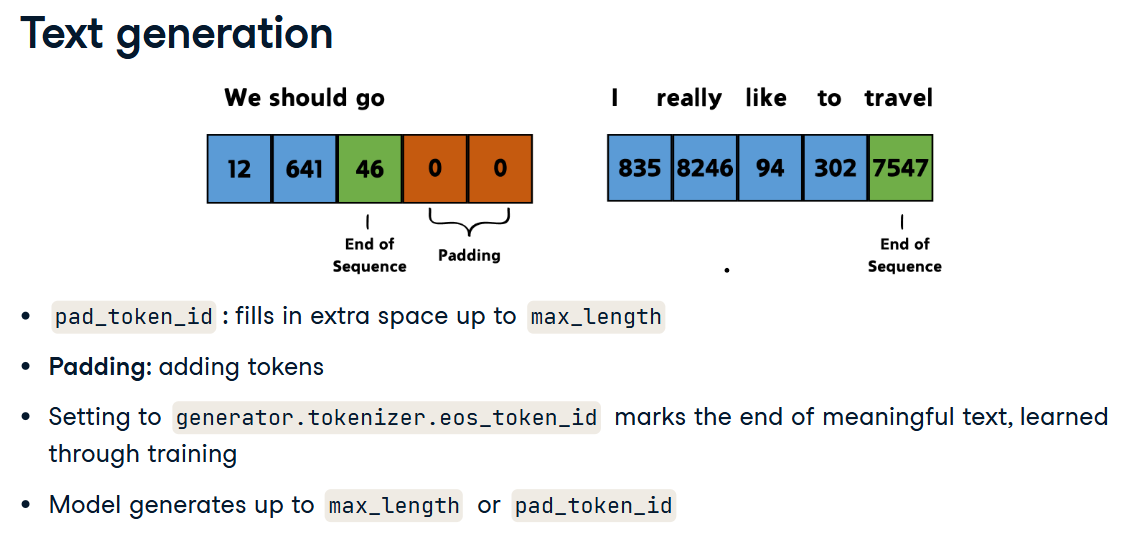

We can control the output by being more specific in the prompt or including additional elements to guide the output.

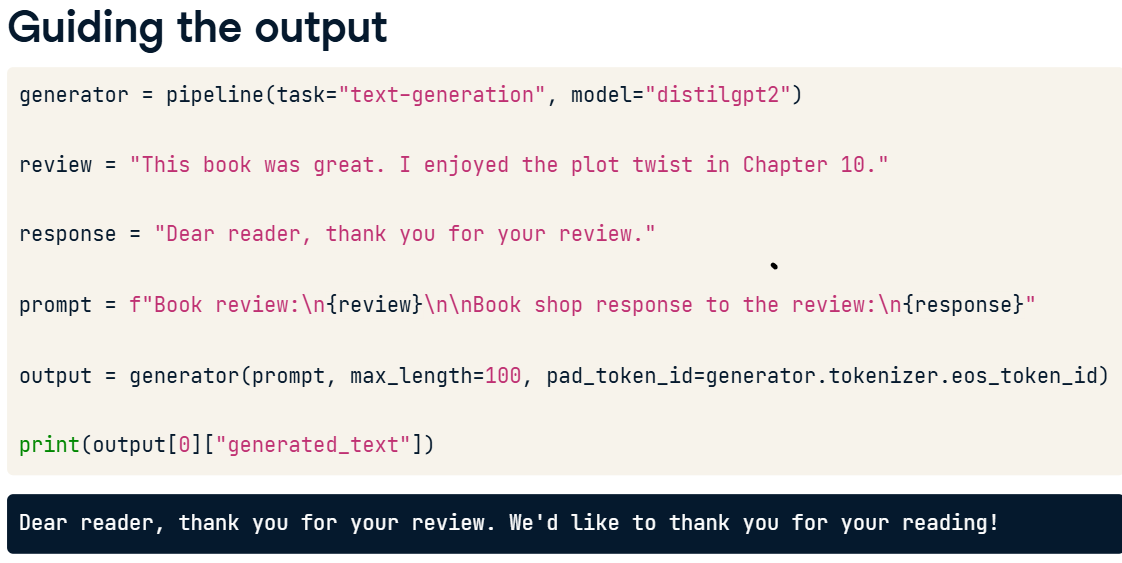

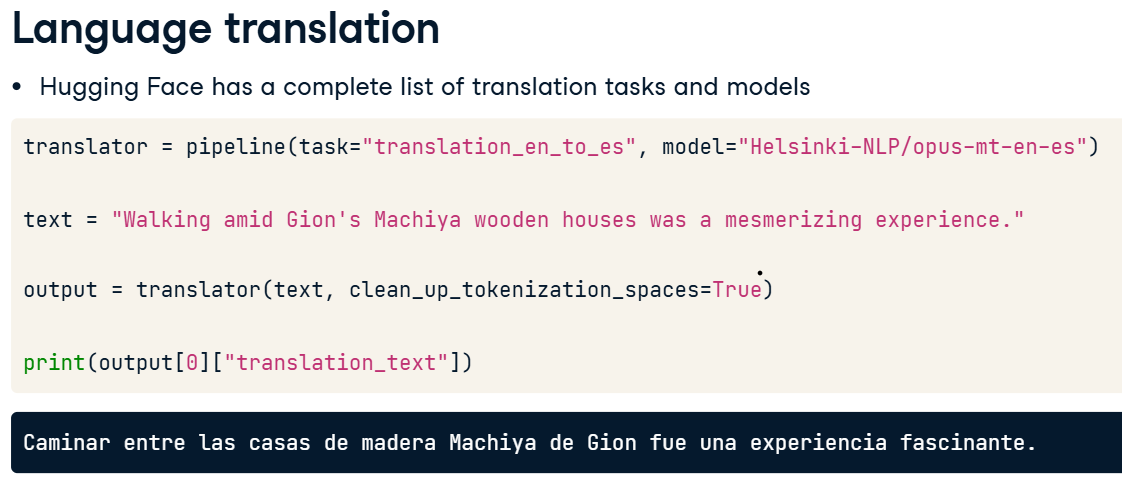

## Understanding the Transformer
Transformers are deep learning architectures for processing, understanding, and generating human-like text.

Transformer is a type of deep learning model introduced in the 2017 paper "Attention Is All You Need" by Vaswani et al. It revolutionized natural language processing by replacing earlier sequential models (like RNNs and LSTMs) with a fully parallelizable and highly scalable architecture.

Key Components of a Transformer:  
Self-Attention Mechanism  

        This allows the model to weigh the importance of each word in a sentence relative to the others.
        For example, in the sentence:
        "The cat sat on the mat, and it was soft." — the model uses attention to link "it" back to "the mat".

Positional Encoding  

    Since transformers don’t process text in sequence (like RNNs do), they need positional information added to understand word order.

Encoder and Decoder Structure (in the original model)  


    Encoder: Processes the input (e.g., a sentence in English).

    Decoder: Generates the output (e.g., a translation in French).
    In many LLMs (like GPT), only the decoder is used.

Feedforward Neural Networks  

    After attention, the output goes through a standard neural network layer to capture more complex transformations.

Layer Normalization and Residual Connections  

    These help stabilize training and preserve information across deep layers.

Why is the Transformer Powerful?  

    Handles long-range dependencies better than earlier models.

    Processes all words in parallel, making it faster to train.

    Scales well with data and compute, which is why it powers large models like GPT-4, BERT, and T5.


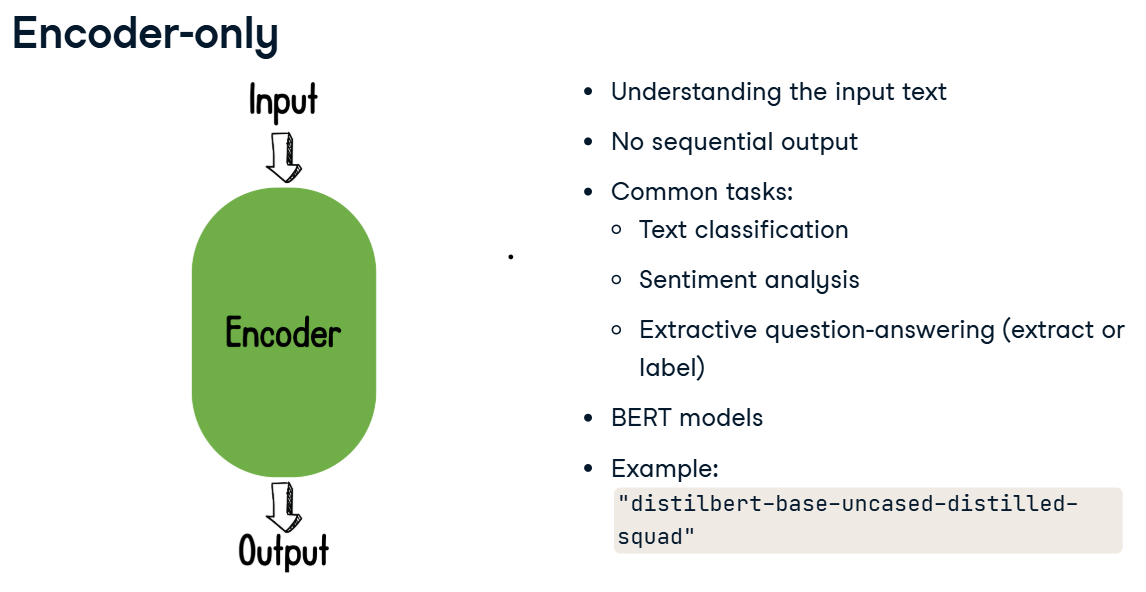

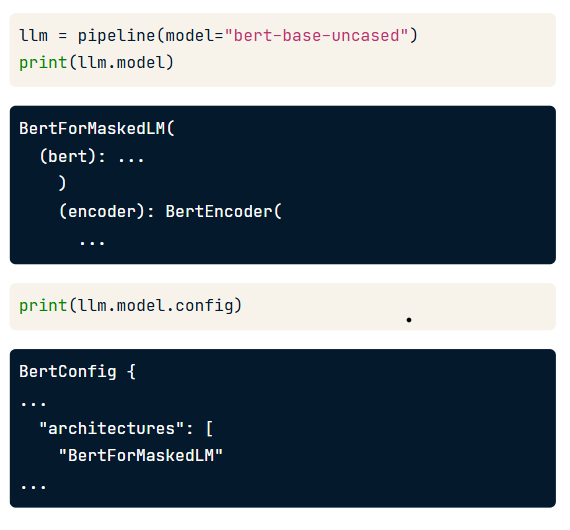

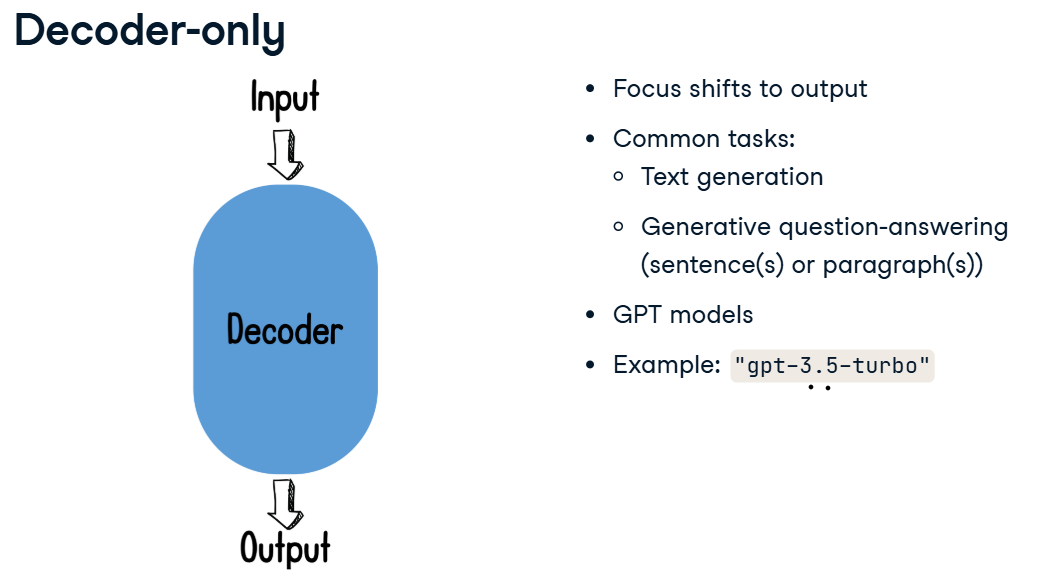

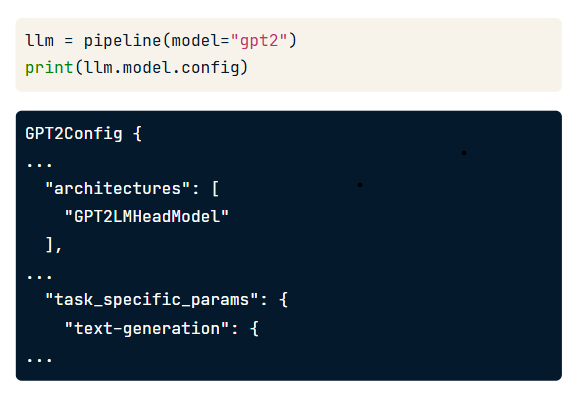

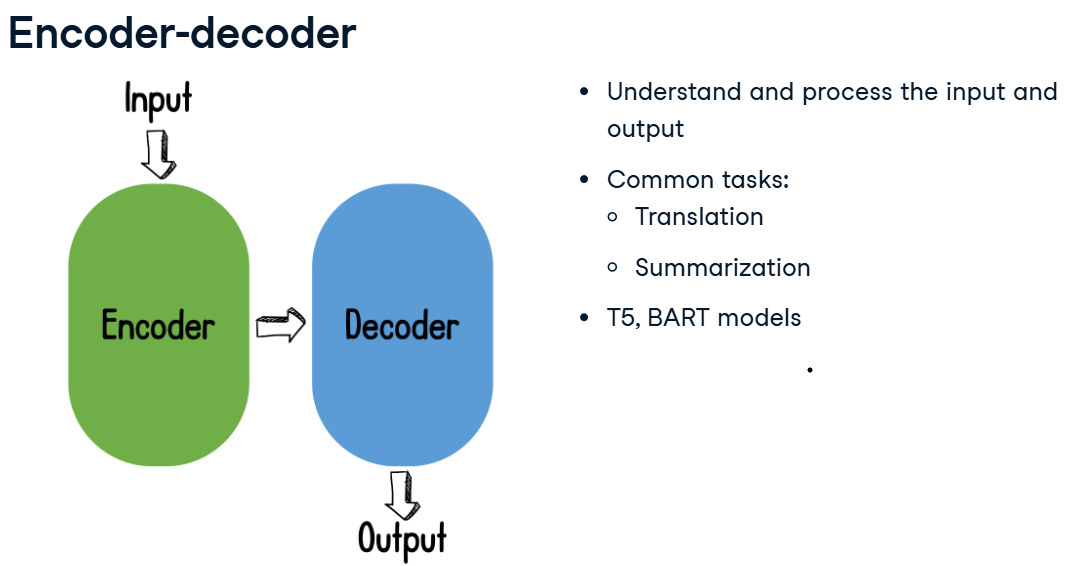

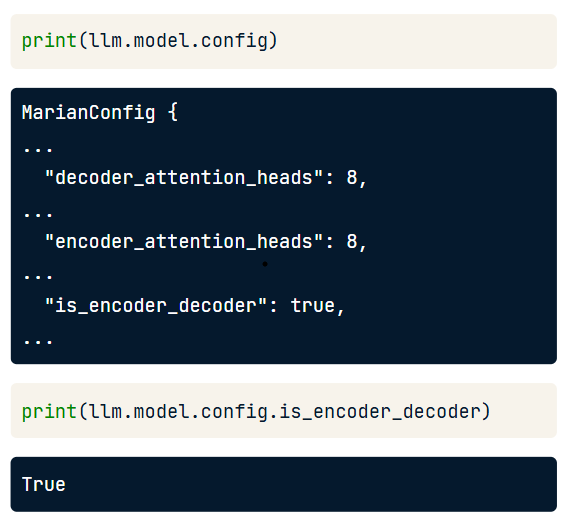

# Part 2: Fine tuning LLMs

## Preparing for fine tuning
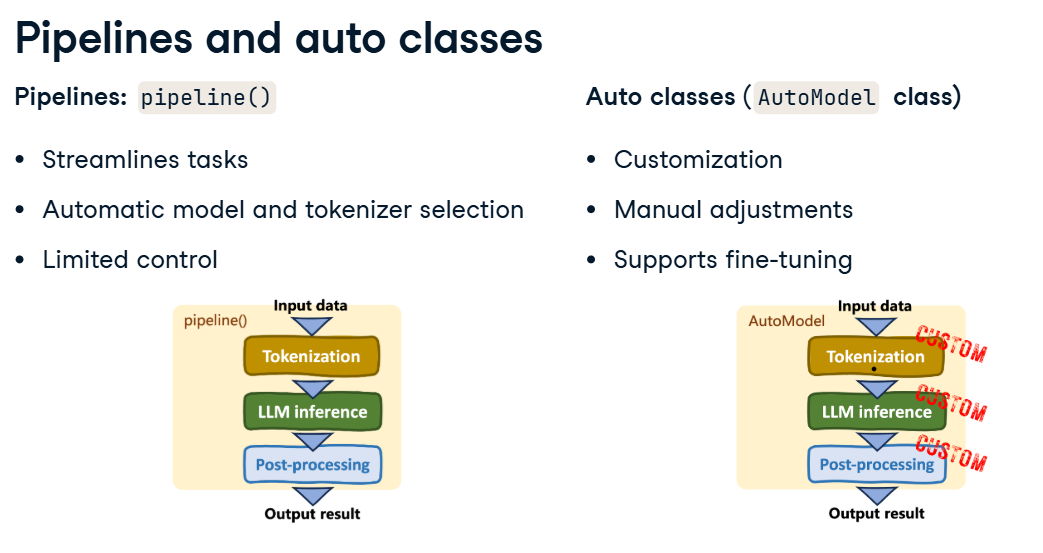

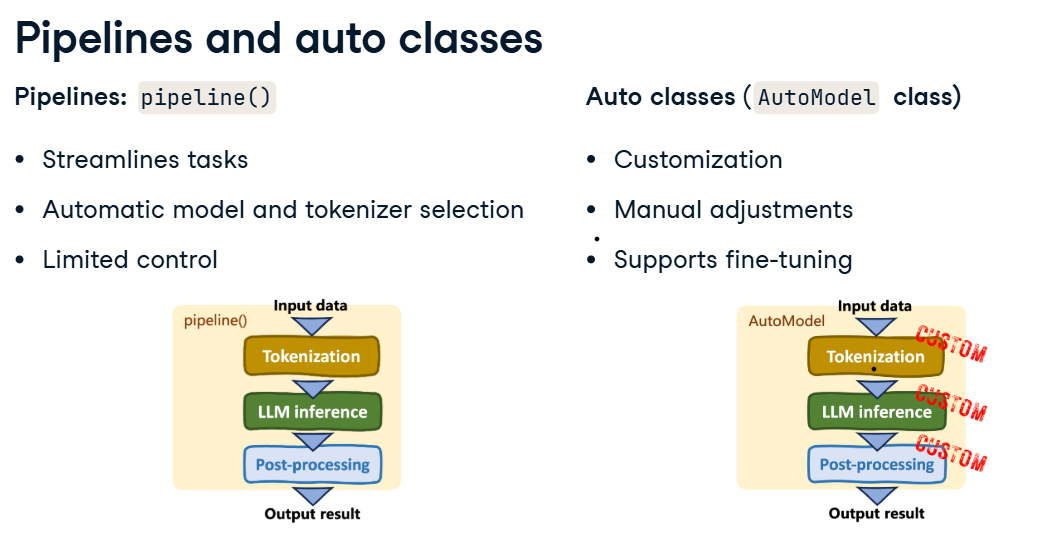

To begin fine-tuning, we prepare the dataset to ensure the model learns the right patterns. The Hugging Face hub offers a datasets library with a vast collection great for experimentation.

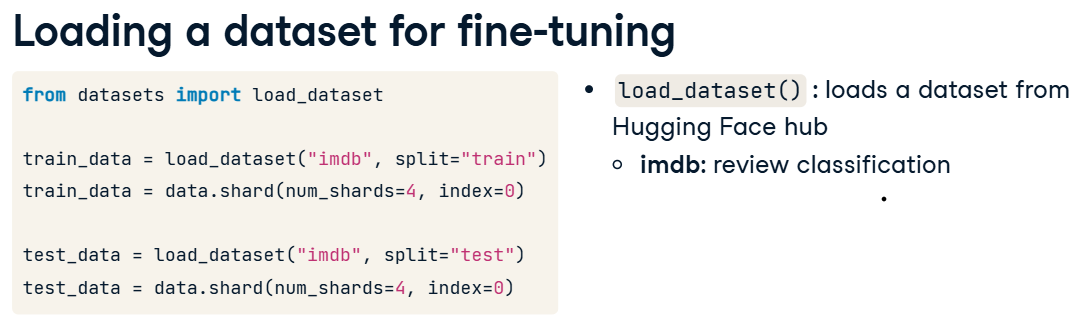

We use .shard() to split this large dataset into four chunks and selecting the first chunk to save with index equals zero. We've done this to speed up training; the extraction process will differ depending on the data and computational needs.

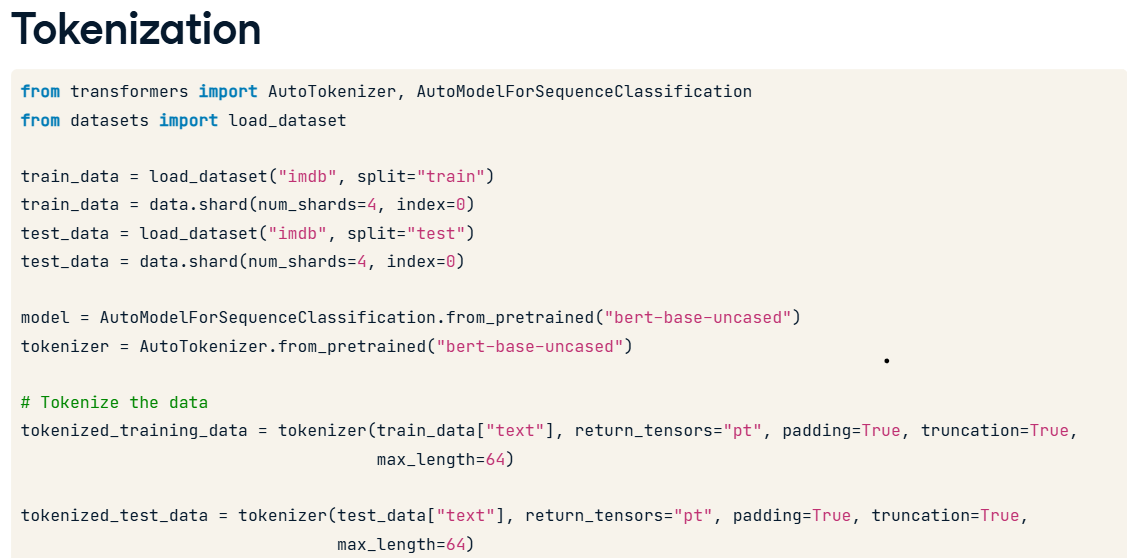
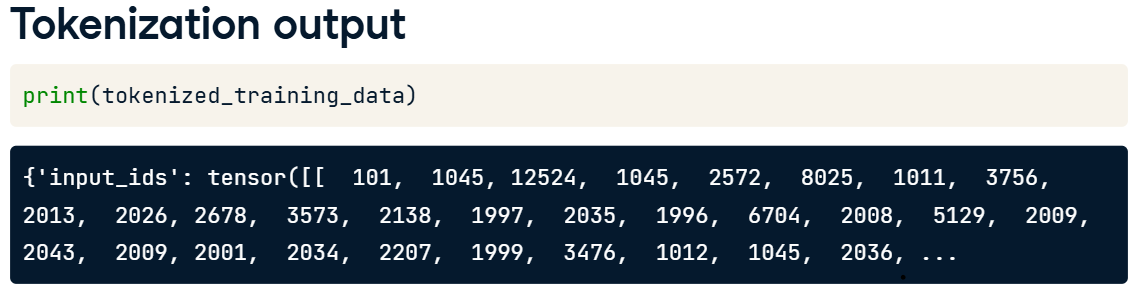

If more control is needed, we can tokenize a dataset in batches or row by row with a custom function and the .map() method, setting batches to True or False, respectively. The result will be a new dataset object with new columns for the tokenized data, which is required for the training loop. 
### Note that the .map() method does not accept list formats, only dataset objects.

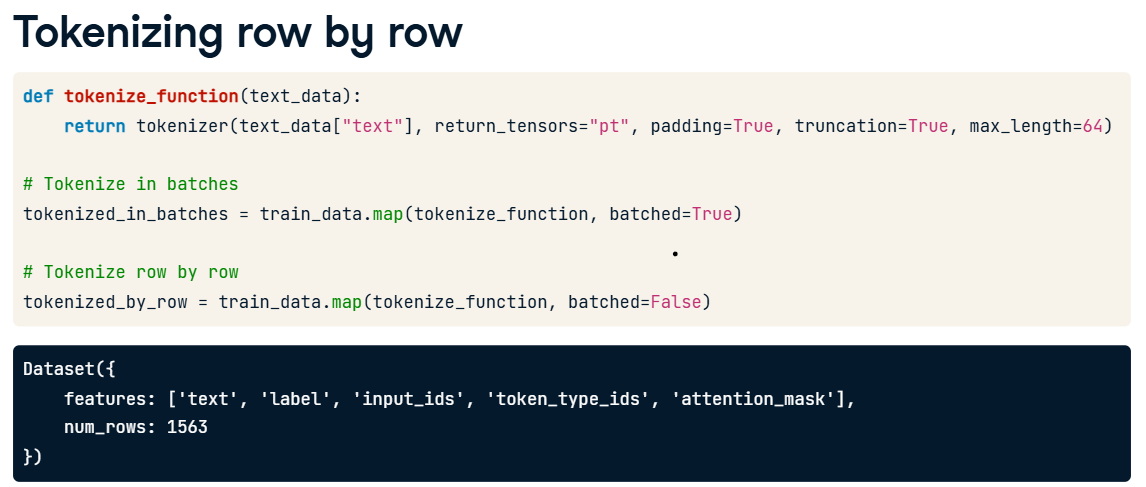

The tokenization we've performed is known as subword tokenization, common in most modern tokenizers. Here, words are split into smaller, meaningful sub-parts of a word, including prefixes and suffixes. For example, with subword tokenization, a word like "unbelievably" would be split into tokens "un", "believ", and "ably".

## Fine tuning thorough training
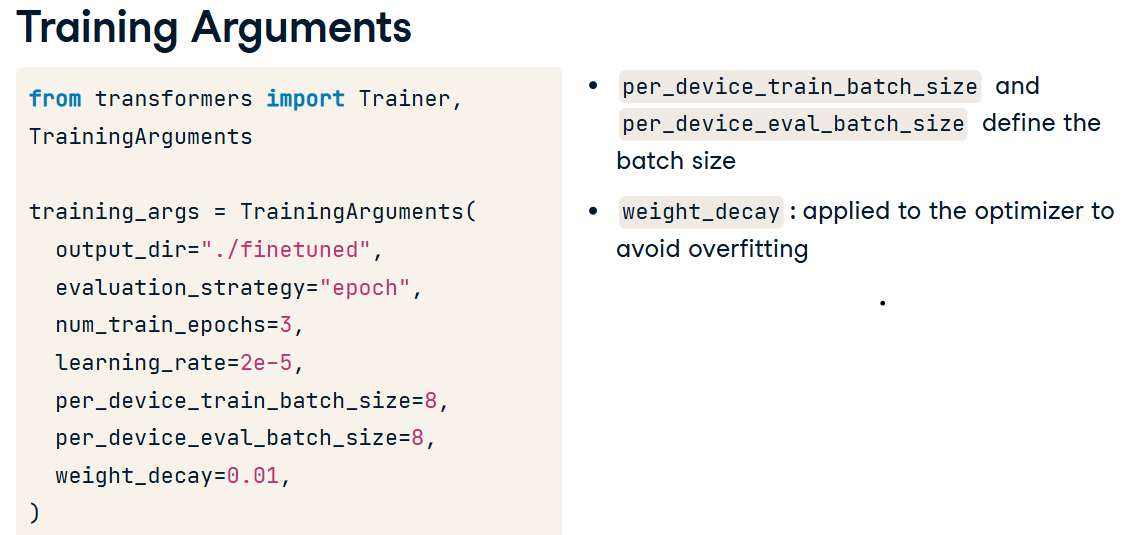

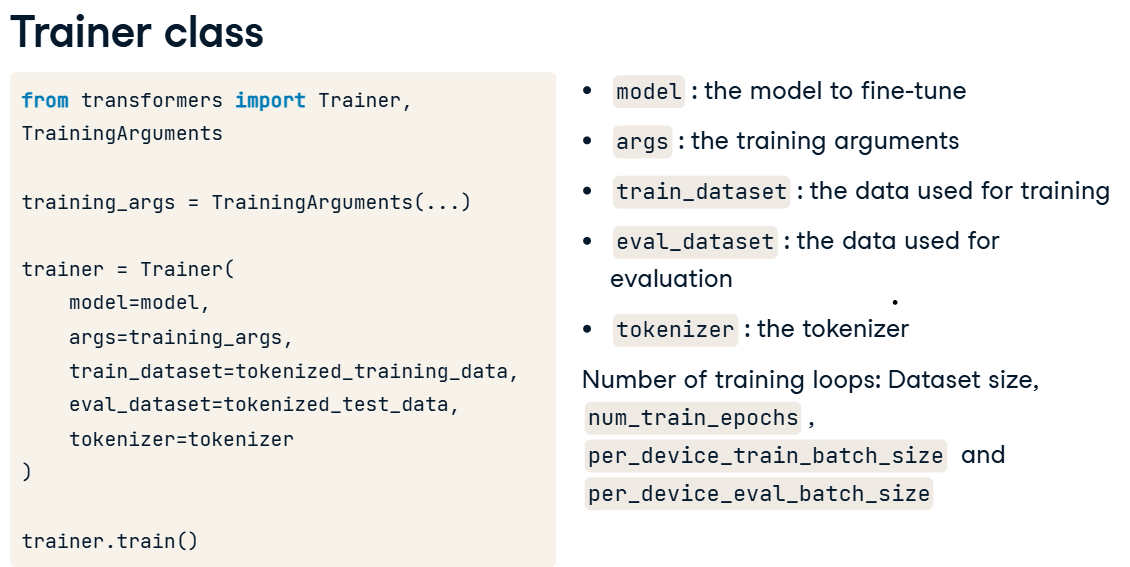

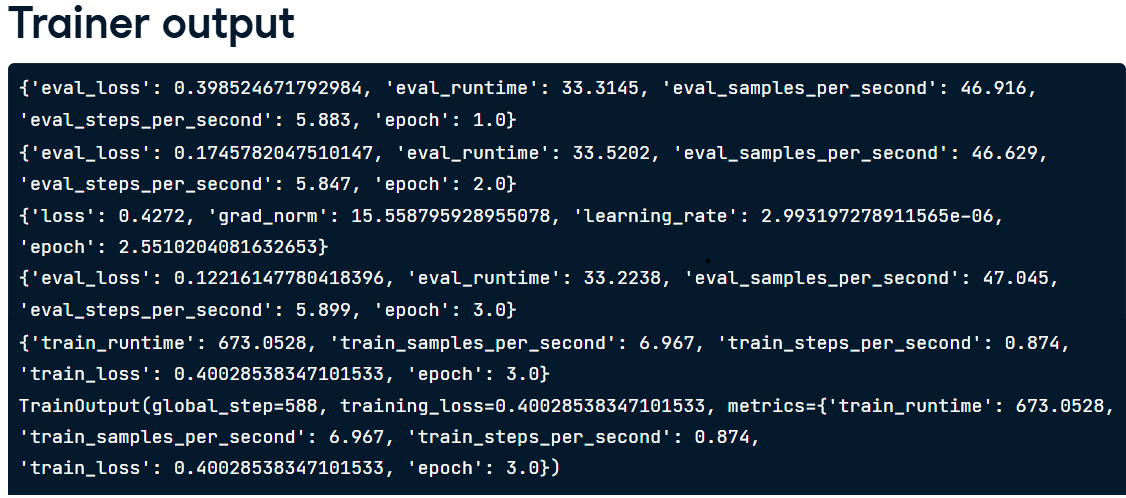

We can use the fine-tuned model to make predictions on new data. First we prepare the new input data using the same tokenizer. Before passing these inputs through the fine-tuned model, we wrap this process in torch.no_grad to disable gradient tracking since these aren't needed for evaluation. We extract the predicted class with .argmax() and print them using a for loop for better readability.

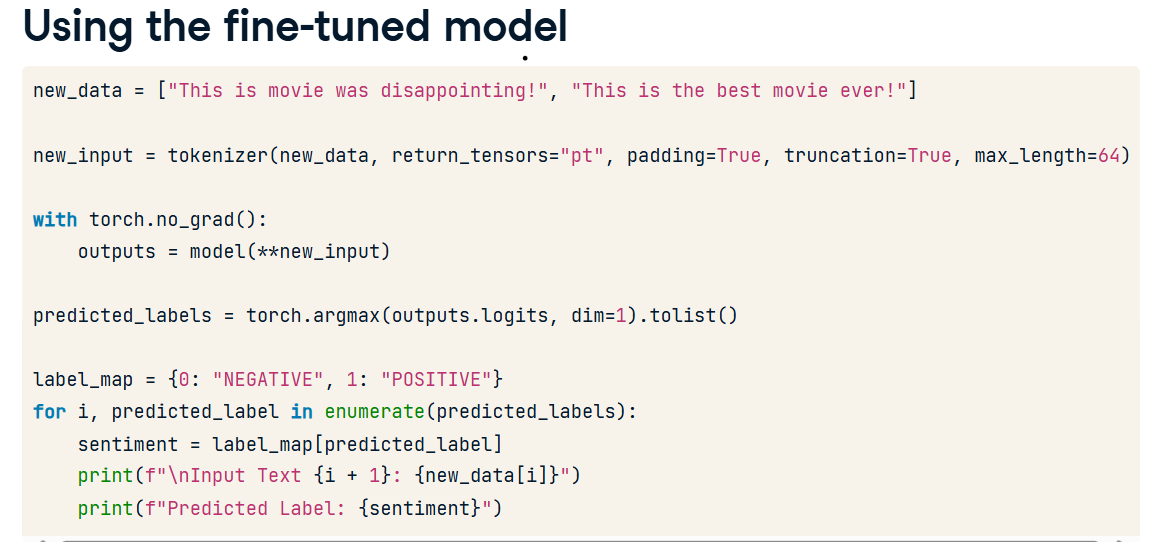

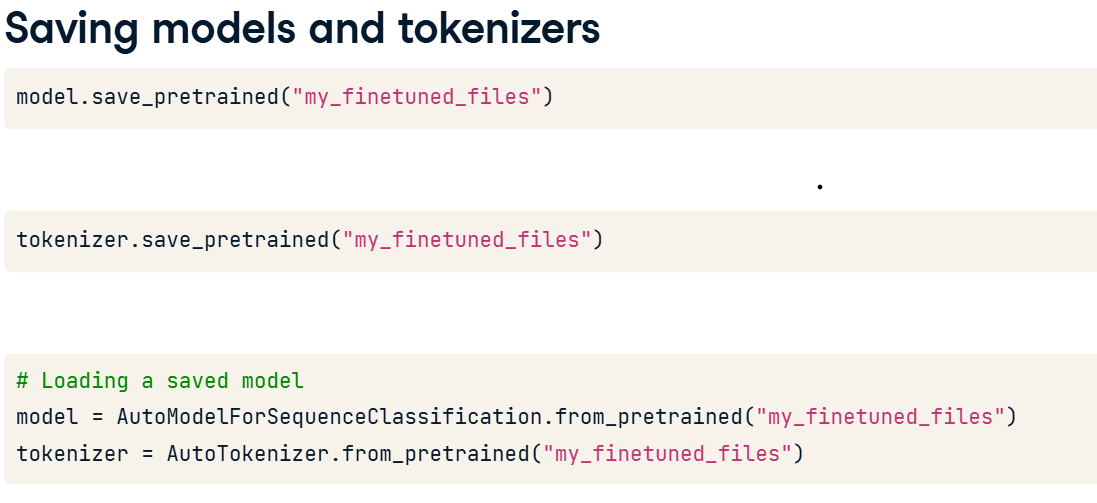

## Fine tuning approaches
Fine-tuning involves taking a pre-trained model and re-training it with domain-specific data to solve a particular downstream task. Consider a general-purpose summarization model fine-tuned on a dataset of chemistry articles to specialize in summarizing chemistry papers. There are two different fine-tuning approaches depending on how the model weights are updated.

One is full-fine tuning, which entails updating weights across the entire model and being more computationally expensive. This is what we've done so far.

The other is partial fine-tuning, where weights in lower layers of the model body responsible for capturing general language understanding remain fixed, updating only the task-specific layers in the model head only. The choice of the approach depends on the specific use case, task-specific data, and hardware computing capabilities.

### Transfer learning
transfer learning adapts a previously trained model on one task to a different but related task. While fine-tuning typically involves training on a smaller dataset for a specific task, transfer learning leverages knowledge gained in one domain to enhance performance in another related domain.

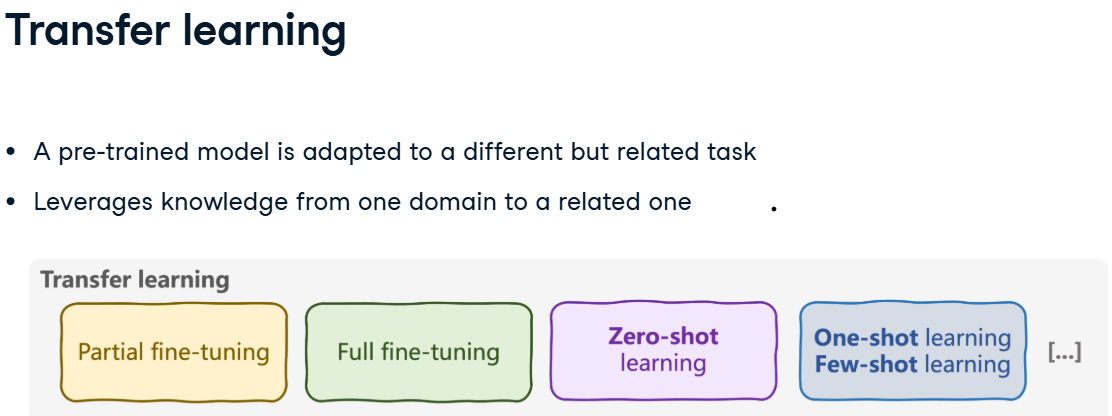

### N-shot learning
This is where a model is trained to generalize to a new task based on the number of examples it has seen during training. For example, in zero-shot learning, often used when data are scarce, a model is trained to generalize to new tasks never seen during training. Exposing a model to one or a few specific examples is known as one-shot and few-shot learning.

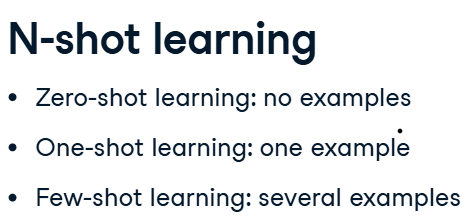

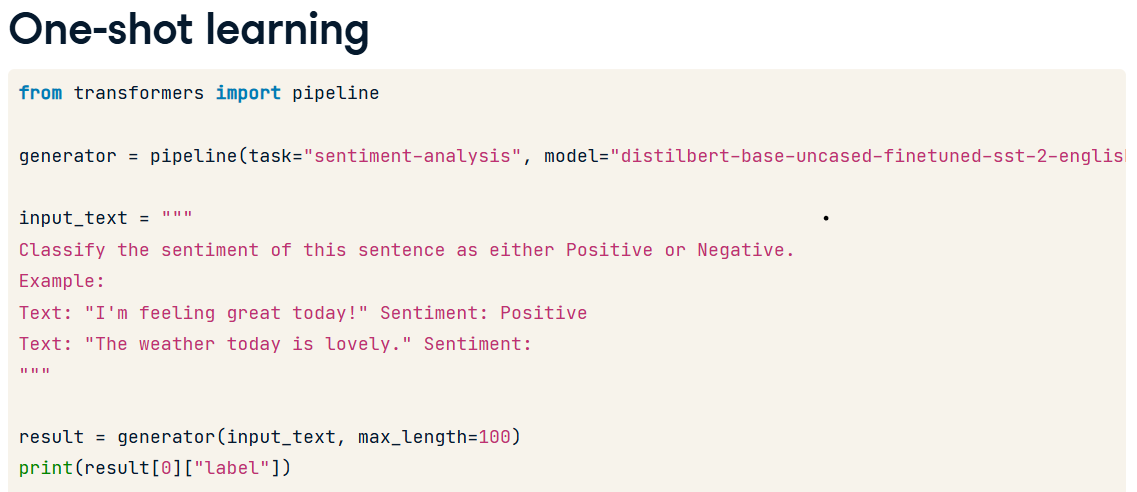

# Part 3: Evaluating LLM Performance

## The evaluate library
We may be familiar with classical metrics, like accuracy, used to evaluate machine learning models. While these can also be applied to LLMs, language tasks usually require more comprehensive and task-specific metrics. Hugging Face's Evaluate library was created to address this need.

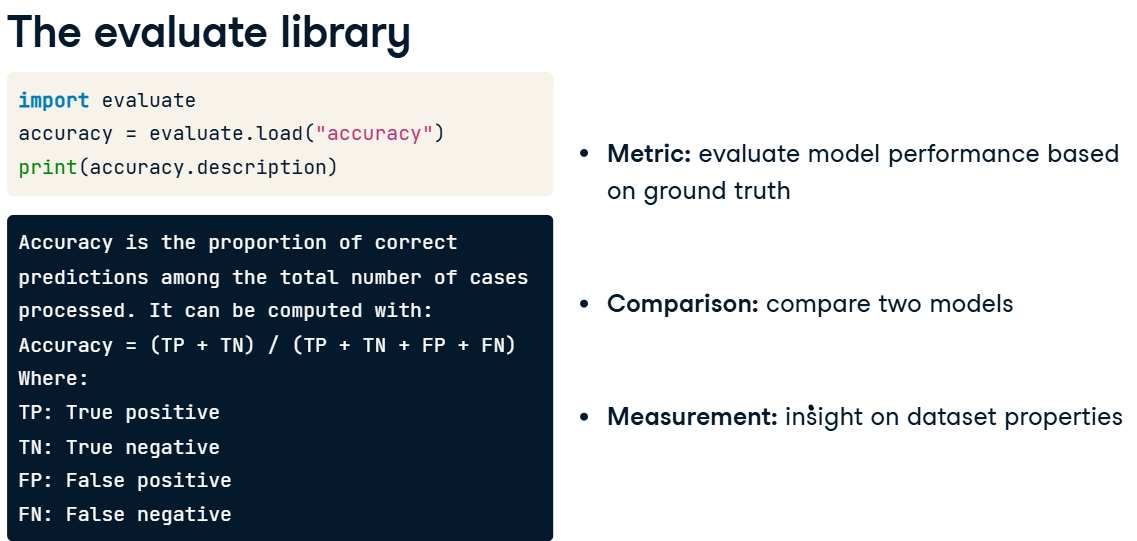

By accessing the features attribute of a metric, we can inspect the required inputs for its computation. 

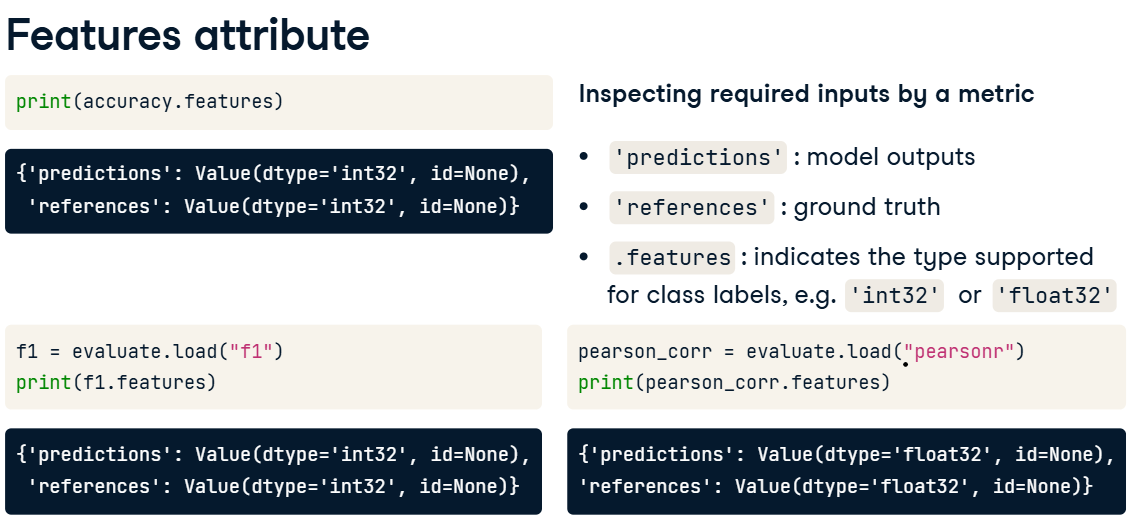

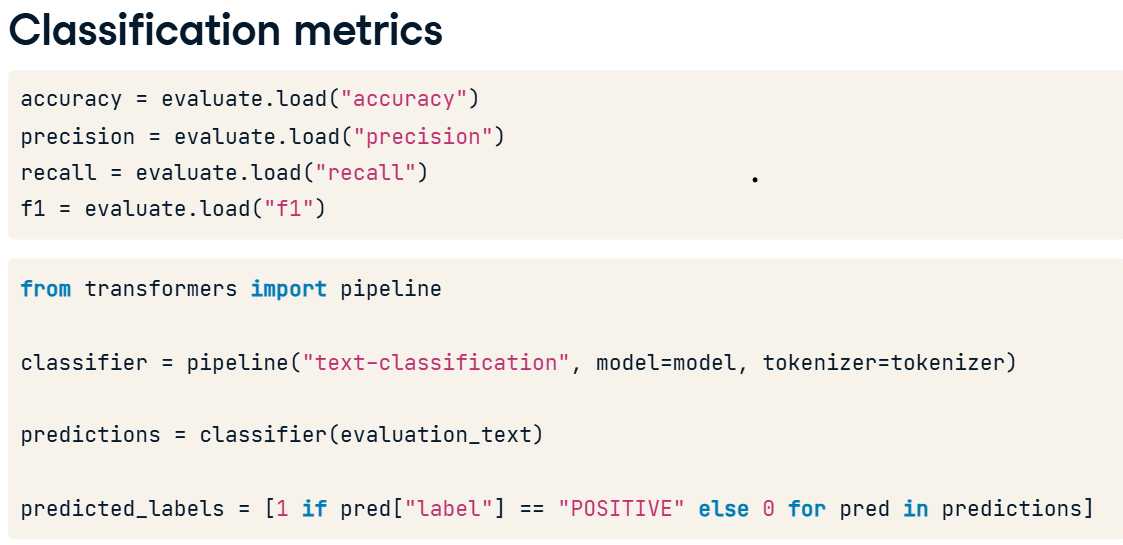

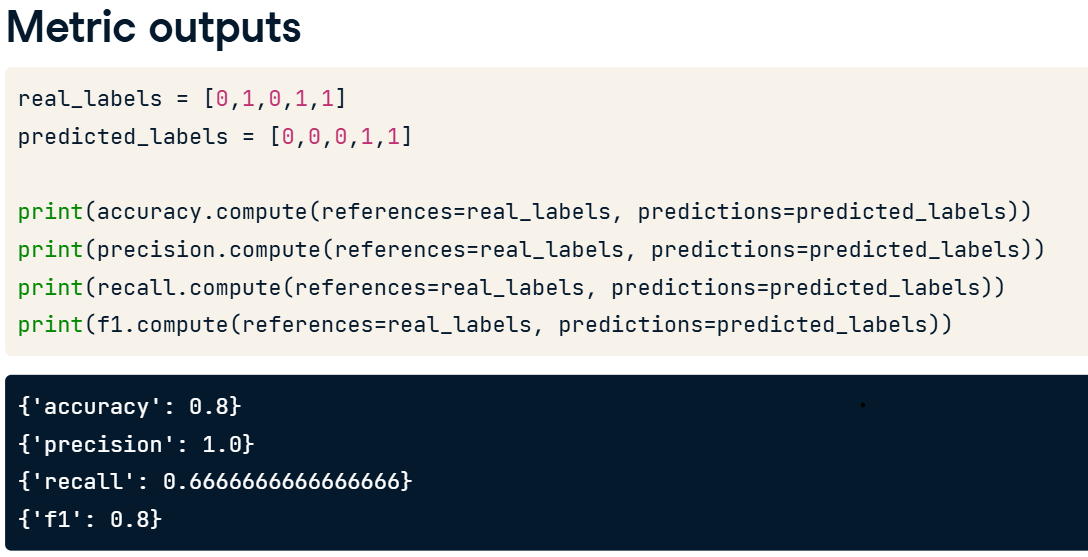

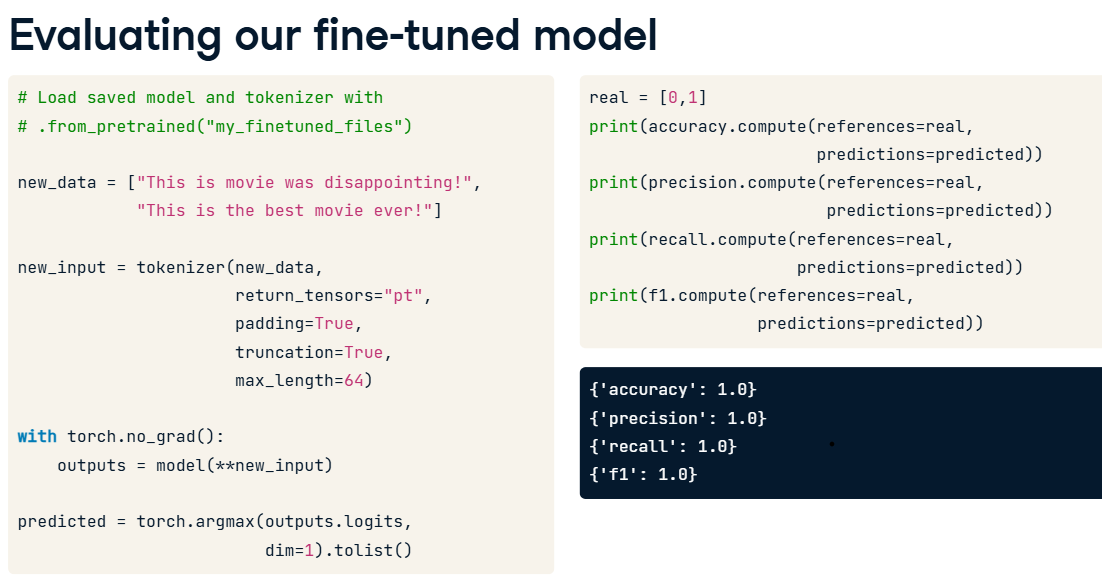

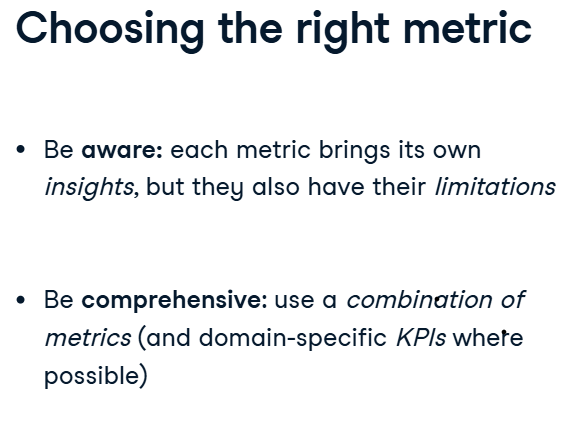

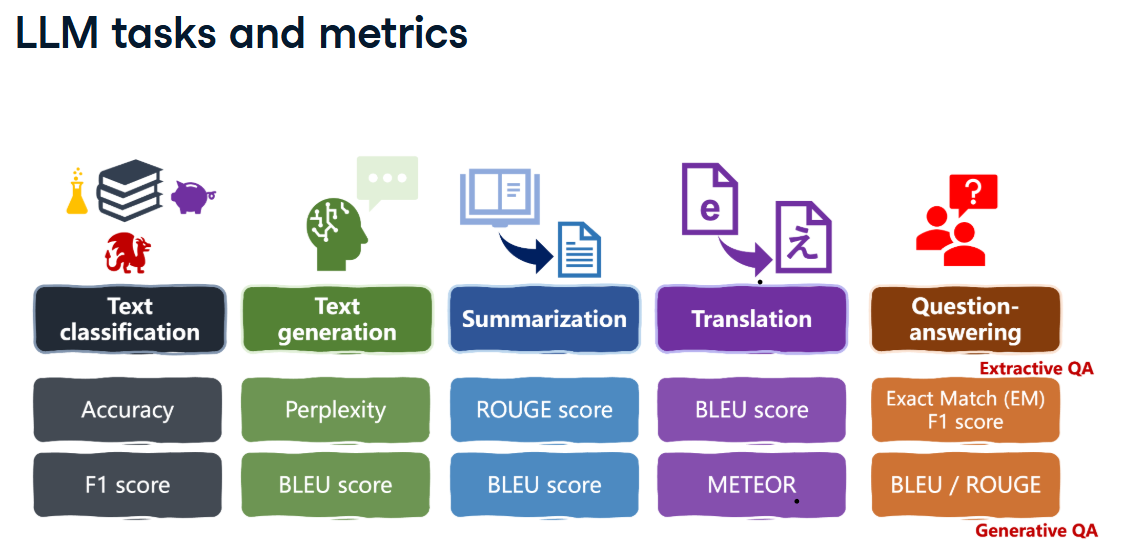

## Metrics for language tasks: perplexity and BLEU

Perplexity measures the model's accuracy and confidence in predicting the next word in a sentence or sequence. In general, a lower perplexity score indicates higher confidence in the predictions.

To see the generated text, we need to turn the input text into token ids, then back into text for the output. This is achieved with .encode() to apply the tokenizer, .generate() to obtain the token ids of the generated text, and .decode() to convert these ids into human readable text.

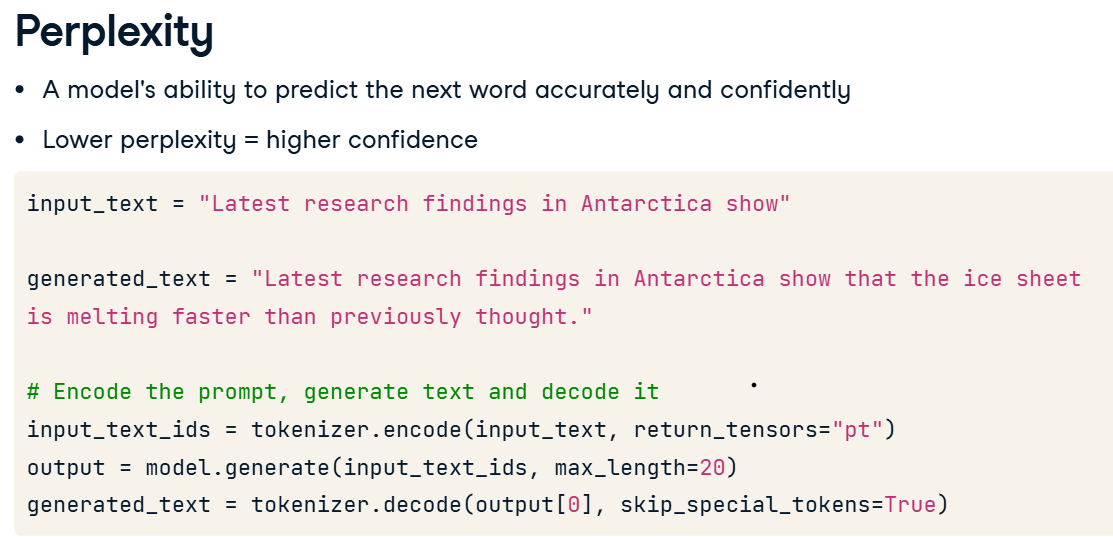

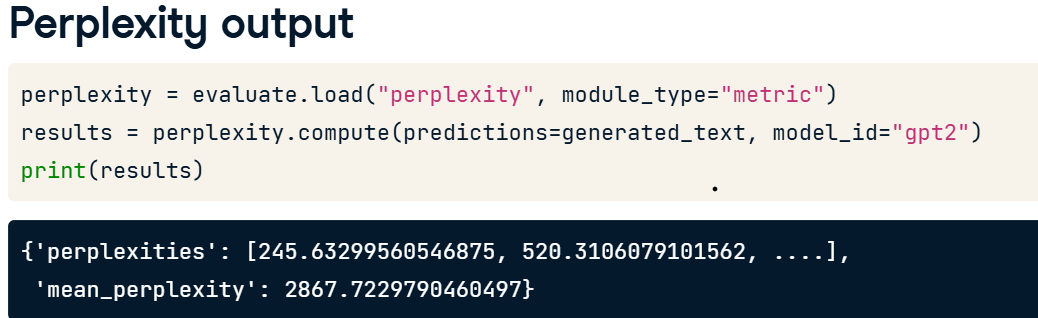

BLEU can also be used to evaluate text generation, as well as summarization and translations. It measures the quality of an LLMs outputs against some references provided by humans. To use the metric, these LLM predictions and human references need to be stored into variables.

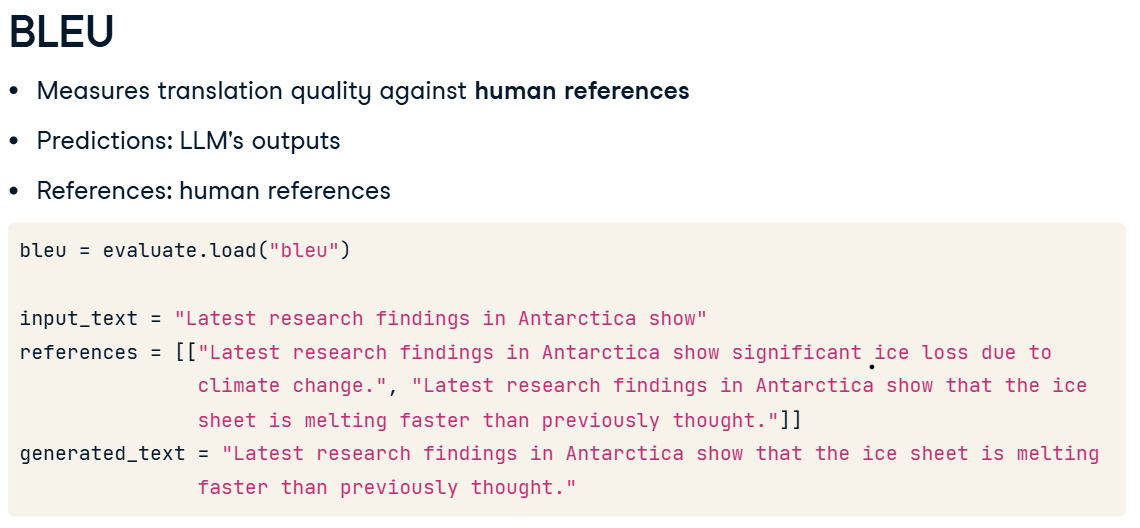

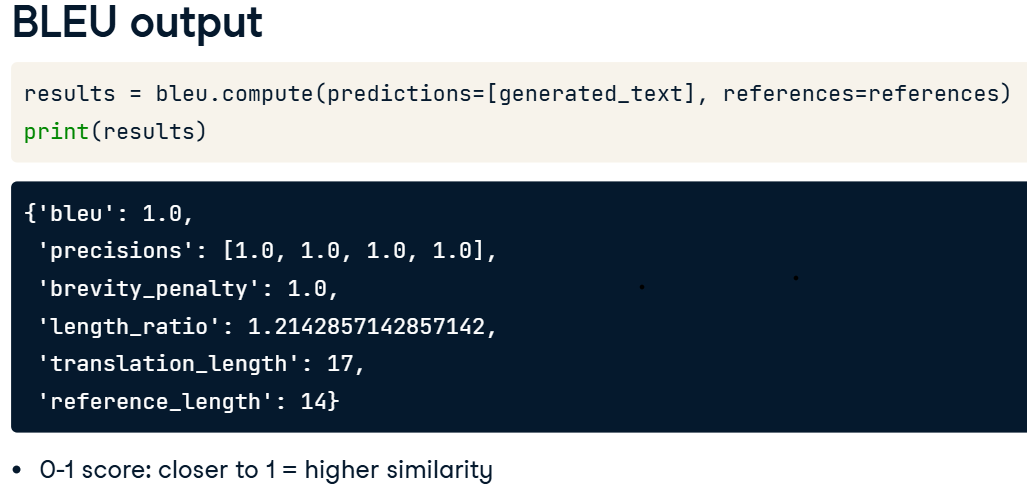

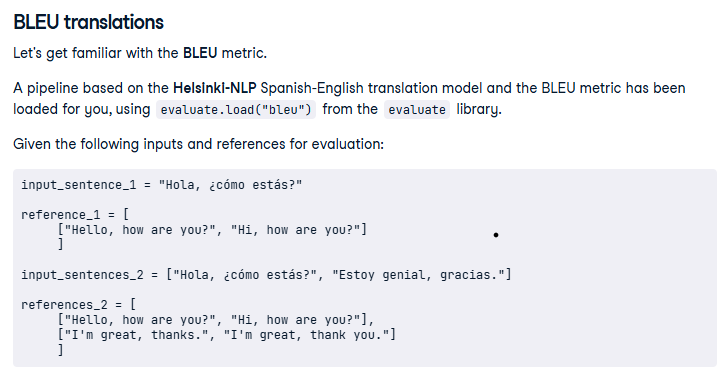
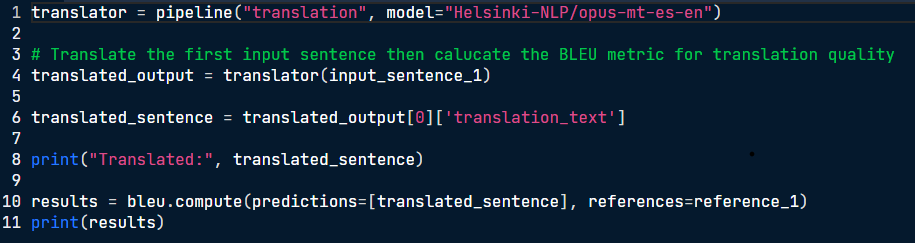
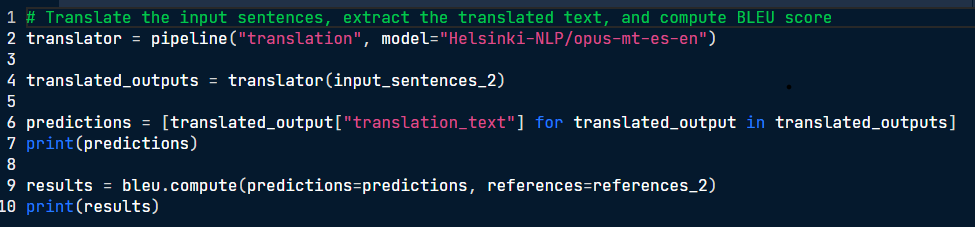

## Metrics for language tasks: ROUGE, METEOR, EM
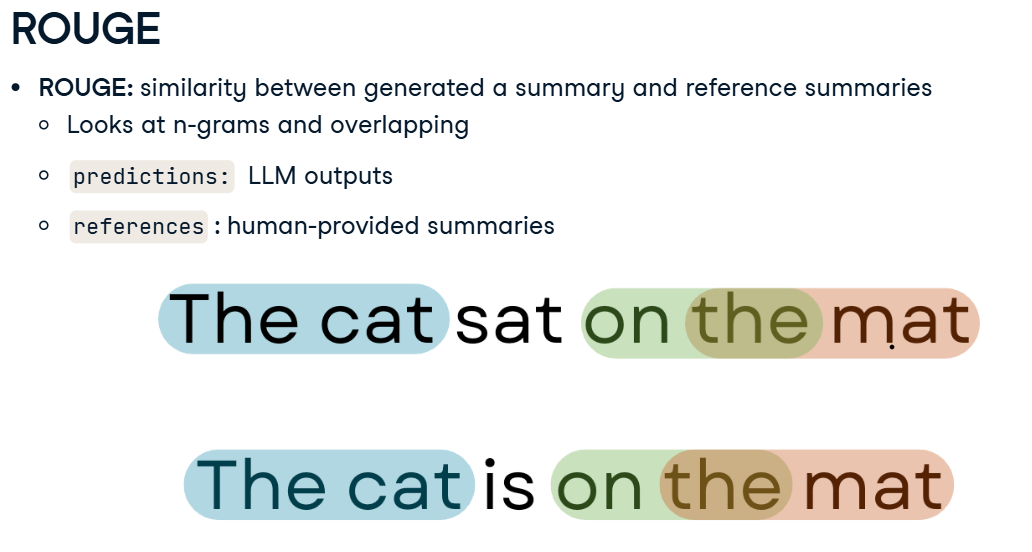

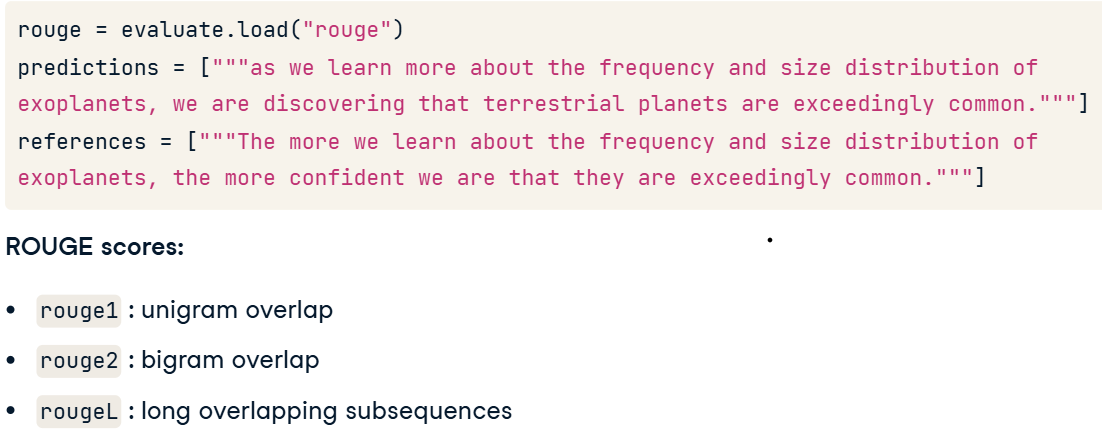

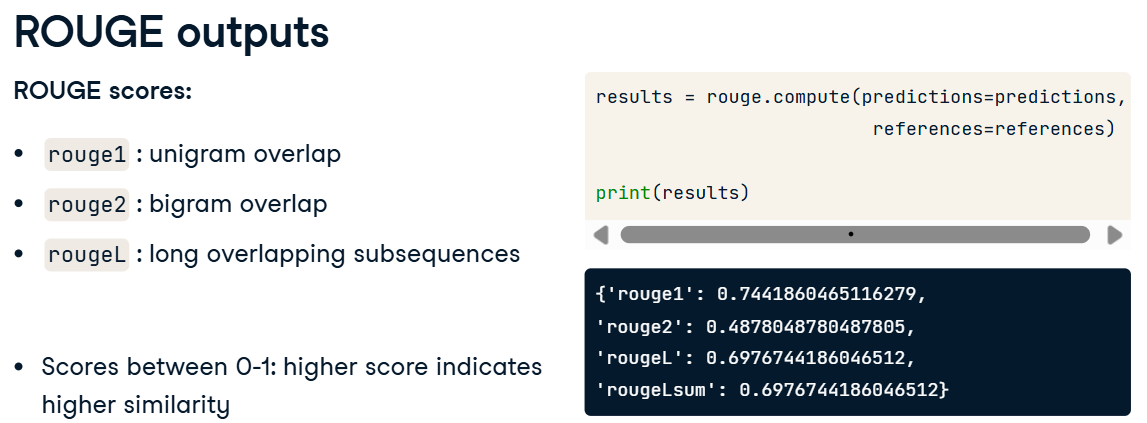

METEOR incorporates more linguistic features into evaluation, such as variations in words through stemming, capturing words with similar meanings, and penalizing errors in word order. Let's compare it to BLEU in a translation scenario. 

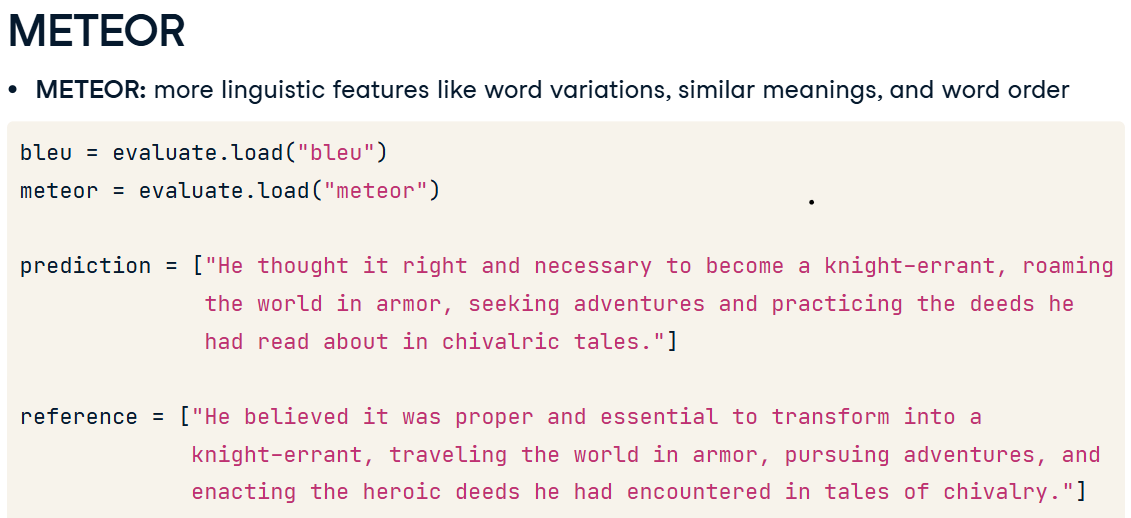
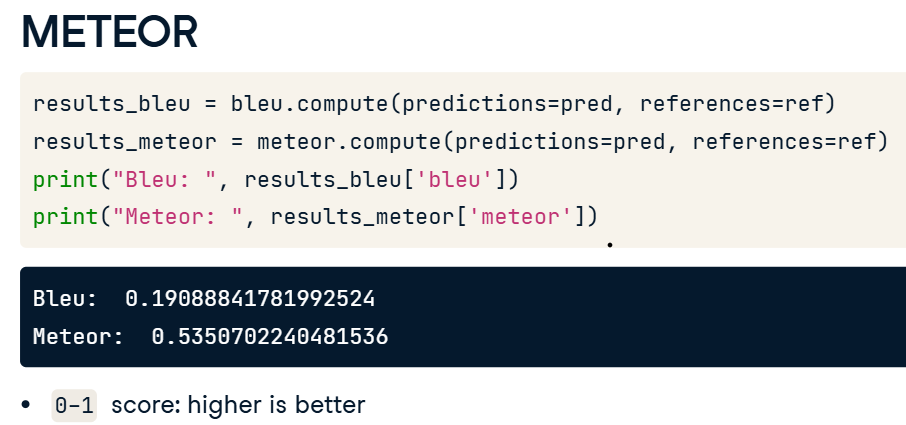

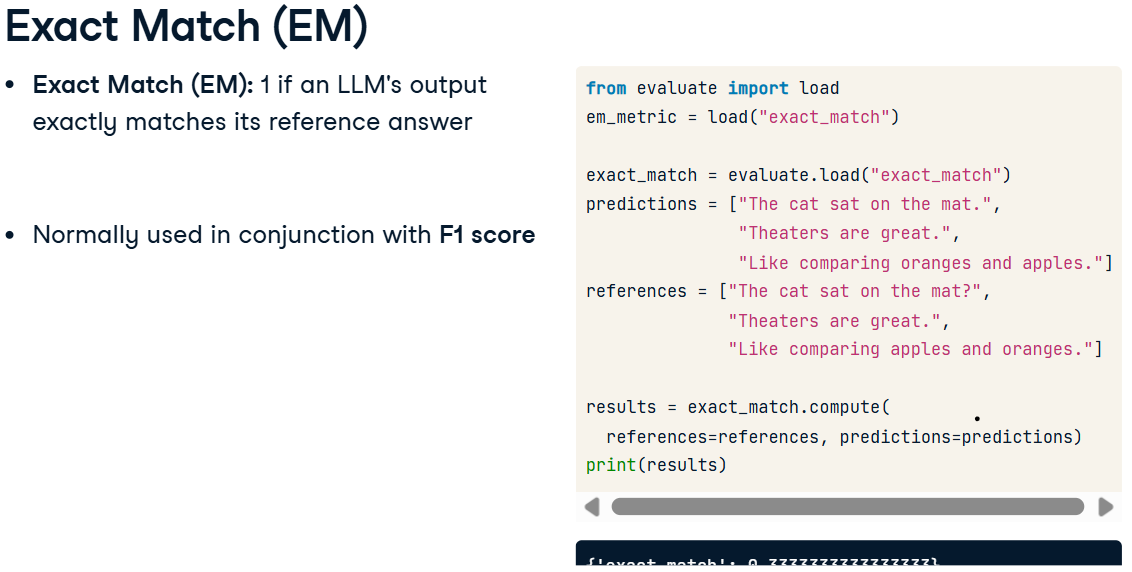